In [12]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [13]:
def c6_data():
    df = pd.read_csv('data.csv')
    df.drop_duplicates(inplace=True)

    x = df.iloc[:, :2].values
    y = df.iloc[:, 2].values

    # 归一化
    scaler_x = StandardScaler()
    x = scaler_x.fit_transform(x)

    scaler_y = StandardScaler()
    y = y.reshape(-1, 1)
    y = scaler_y.fit_transform(y)

    # 划分数据集
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=666)

    return x_train, x_test, y_train, y_test, scaler_x, scaler_y

# 获取数据
x_train, x_test, y_train, y_test, scaler_x, scaler_y = c6_data()


In [14]:
# 假设每个样本有10个时间步长
sequence_length = 10

# 生成时间序列数据
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

# 创建训练和测试序列
x_train_seq = create_sequences(x_train, sequence_length)
x_test_seq = create_sequences(x_test, sequence_length)

# 调整 y_train 和 y_test 的形状以匹配序列
y_train_seq = y_train[sequence_length - 1:]
y_test_seq = y_test[sequence_length - 1:]


In [15]:
# 定义 LSTM 模型
model = Sequential()
model.add(LSTM(32, input_shape=(sequence_length, x_train_seq.shape[2]), return_sequences=True))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])


In [16]:
from tensorflow import keras
model = keras.models.load_model("./lstmmodel/model_lstm_weight")


In [16]:
# 训练模型
history = model.fit(x_train_seq, y_train_seq, epochs=20, batch_size=32, validation_data=(x_test_seq, y_test_seq))


Epoch 1/20


2024-11-15 23:39:26.148143: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fe8a5222250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-15 23:39:26.148166: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2024-11-15 23:39:26.152706: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-15 23:39:26.280811: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2589/2589 [==============================] - 13s 4ms/step - loss: 0.1341 - mae: 0.2552 - val_loss: 0.0826 - val_mae: 0.2041
Epoch 2/20
2589/2589 [==============================] - 9s 4ms/step - loss: 0.0832 - mae: 0.2098 - val_loss: 0.0815 - val_mae: 0.2086
Epoch 3/20
2589/2589 [==============================] - 9s 4ms/step - loss: 0.0810 - mae: 0.2046 - val_loss: 0.0782 - val_mae: 0.1997
Epoch 4/20
2589/2589 [==============================] - 9s 4ms/step - loss: 0.0793 - mae: 0.2009 - val_loss: 0.0767 - val_mae: 0.1982
Epoch 5/20
2589/2589 [==============================] - 9s 4ms/step - loss: 0.0779 - mae: 0.1982 - val_loss: 0.0804 - val_mae: 0.1992
Epoch 6/20
2589/2589 [==============================] - 9s 4ms/step - loss: 0.0770 - mae: 0.1962 - val_loss: 0.0779 - val_mae: 0.1959
Epoch 7/20
2589/2589 [==============================] - 9s 4ms/step - loss: 0.0767 - mae: 0.1959 - val_loss: 0.0757 - val_mae: 0.1957
Epoch 8/20
2589/2589 [==============================] - 9s 4ms/step - lo

In [17]:
# 保存模型权重
model.save_weights('lstmmodel/lstm_weights.h5')

# 创建存储scaler的文件夹
scaler_folder = os.path.join('lstmmodel', 'scalers')
os.makedirs(scaler_folder, exist_ok=True)

# 保存scaler
joblib.dump(scaler_x, os.path.join(scaler_folder, 'scaler_x.pkl'))
joblib.dump(scaler_y, os.path.join(scaler_folder, 'scaler_y.pkl'))


['lstmmodel/scalers/scaler_y.pkl']

In [17]:
# 预测并计算额外的指标
y_pred = model.predict(x_test_seq)

# 计算均方误差 (MSE)
mse = mean_squared_error(y_test_seq, y_pred)
print(f"MSE: {mse}")

# 计算均方根误差 (RMSE)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

# 计算平均绝对误差 (MAE)
mae = mean_absolute_error(y_test_seq, y_pred)
print(f"MAE: {mae}")

# 计算 R²
r2 = r2_score(y_test_seq, y_pred)
print(f"R²: {r2}")


647/647 [==============================] - 2s 2ms/step
MSE: 0.0740289419758726
RMSE: 0.2720826013839779
MAE: 0.18951886151736597
R²: 0.9265952120775854


In [19]:
model.save('lstmmodel.h5')

/root/miniconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
# 保存模型
model_path = './lstmmodel/model_lstm_weight'
os.makedirs(os.path.dirname(model_path), exist_ok=True)
model.save(model_path)
print("Model saved to disk.")


INFO:tensorflow:Assets written to: ./lstmmodel/model_lstm_weight/assets


INFO:tensorflow:Assets written to: ./lstmmodel/model_lstm_weight/assets


Model saved to disk.


In [ ]:
# 获取训练和验证 MAE
train_mae = history.history['mae']
val_mae = history.history['val_mae']

# 获取训练和验证损失
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# 计算平均验证损失和MAE
avg_val_loss = np.mean(val_loss)
avg_val_mae = np.mean(val_mae)

# 计算损失的变化率
loss_diff = np.diff(val_loss)
max_diff_index = np.argmax(np.abs(loss_diff))

# 自定义放大区间
zoom_epoch_start = 15  # 自定义起始 epoch
zoom_epoch_end = 18   # 自定义结束 epoch

# 自定义虚线框高度和宽度
rect_y_min = 0.073  # 自定义虚线框的下边界
rect_y_max = 0.077  # 自定义虚线框的上边界
rect_x_start = 15   # 自定义虚线框的左边界
rect_x_end = 17      # 自定义虚线框的右边界

# 创建保存图片的文件夹
folder_name = "lstm_fig"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 绘制损失图
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(c1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
loss_file_path = os.path.join(folder_name, 'lstm_loss_plot.png')
plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
print(f"损失图已保存到: {loss_file_path}")

# 绘制局部放大图
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax2.legend(loc='upper left', bbox_to_anchor=(0.095, 1), bbox_transform=ax2.transAxes)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.text(0.99, 0.98, '(c2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# 绘制结合图，将局部放大图嵌入到主图中
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(c1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 嵌入放大损失图
inset_ax = fig.add_axes([0.42, 0.35, 0.5, 0.5])  # [left, bottom, width, height]
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')  # 添加平均值线
inset_ax.set_xlabel('Epoch')
inset_ax.set_ylabel('Loss')
inset_ax.grid(True, linestyle='--', alpha=0.7)
inset_ax.text(0.99, 0.98, '(c2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')


# 添加红色虚线框
rect = plt.Rectangle((rect_x_start, rect_y_min), 
                     rect_x_end - rect_x_start, 
                     rect_y_max - rect_y_min, 
                     edgecolor='red', linestyle='--', linewidth=2, facecolor='none', transform=ax1.transData)
ax1.add_patch(rect)

plt.tight_layout()
combined_file_path = os.path.join(folder_name, 'combined_plot_zoomed.png')
plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
print(f"结合图已保存到: {combined_file_path}")

# 显示图表
plt.show()

In [ ]:

# 确保保存图片的文件夹存在
folder_path = os.path.join('lstm_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)


# 加载保存的scaler
scaler_x = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_x.pkl'))
scaler_y = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_y.pkl'))

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 创建新数据序列
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated, label='True stress-strain', color='#62B197')
plt.plot(strain_truncated, stress_pred_truncated, label='Predicted stress-strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')
plt.legend()
# plt.title('True vs Predicted Stress-Strain Curve')
plt.grid(True)
# 在右下角添加文本 (b1)
plt.text(0.95, 0.05, '(c)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
# 保存图片
plt.savefig(os.path.join(folder_path, 'predicted_vs_true_stress_strain.png'))
plt.show()


78/78 [==============================] - 0s 2ms/step


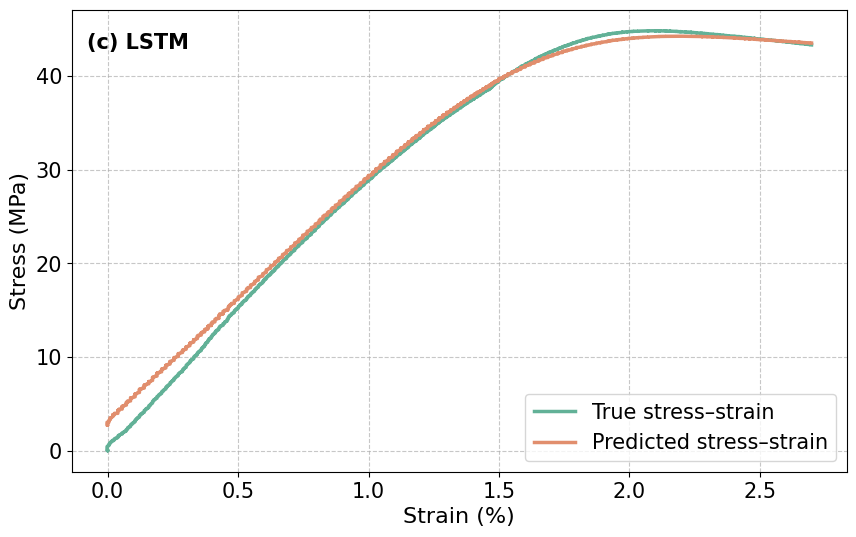

In [28]:
# 确保保存图片的文件夹存在
folder_path = os.path.join('lstm_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 加载保存的scaler
scaler_x = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_x.pkl'))
scaler_y = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_y.pkl'))

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 创建新数据序列（沿用你已有的函数与序列长度）
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 进行预测（沿用你已有的 LSTM 模型对象 model）
y_pred_scaled = model.predict(x_new_seq)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]


# 使用特定的应变阈值，过滤掉 >=2.7 的点
strain_threshold = 2.7
valid_indices = strain_truncated < strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]


# —— 绘图（仅调整样式；不改范围与刻度） ——
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated,
         label='True stress–strain', color='#62B197', linewidth=2.5)
plt.plot(strain_truncated, stress_pred_truncated,
         label='Predicted stress–strain', color='#E18E6D', linewidth=2.5)

# 坐标轴与刻度字号（保持原有刻度/范围，仅放大字体）
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 图例与网格（图例固定右下角；统一网格样式）
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 角标：移到左上角，并标注模型名
plt.text(0.02, 0.95, '(c) LSTM', transform=plt.gca().transAxes,
         fontsize=15, fontweight='bold', ha='left', va='top')

# 保存图片（路径不变）
plt.savefig(os.path.join(folder_path, 'predicted_vs_true_stress_strain.png'),
            dpi=300, bbox_inches='tight')

# 显示并关闭
plt.show()
plt.close()


In [ ]:
# 反归一化预测值和真实值
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_seq_inv = scaler_y.inverse_transform(y_test_seq)

# 绘制预测值和真实值的折线图
plt.figure(figsize=(12, 6))
plt.plot(y_test_seq_inv, label='True Values', color='blue')
plt.plot(y_pred_inv, label='Predicted Values', color='orange')
plt.title('True vs Predicted Values')
plt.xlabel('Samples')
plt.ylabel('Value')
plt.legend()
plt.show()
plt.savefig('Triue and Predicted Values.png')

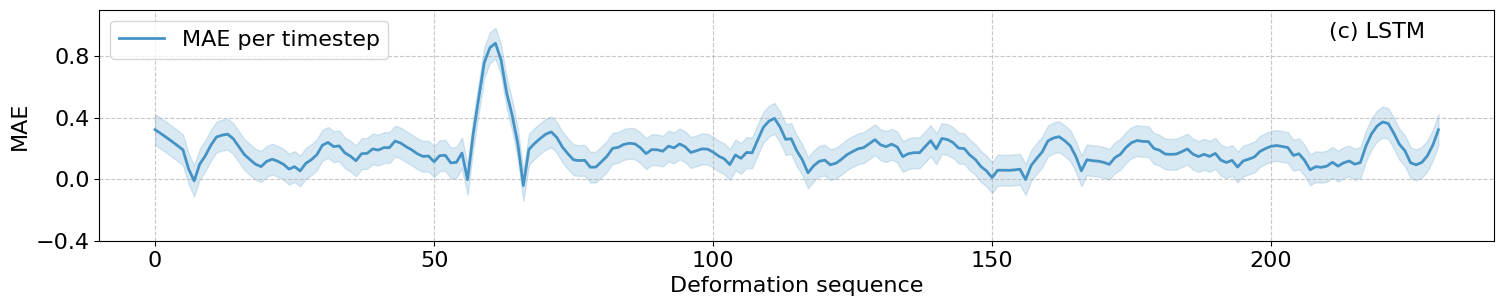

MAE per timestep plot saved and displayed: ./lstm_fig/mae_per_timestep.png


In [27]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator

# 计算每个时间步的 MAE
mae_per_timestep = np.abs(y_test_seq - y_pred).mean(axis=1)

# 采样数据以减少密度（例如，每隔250个点取一个）
sampling_rate = 90
mae_sampled = mae_per_timestep[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)

# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per timestep', color='#4493C4', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.1  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='#4493C4', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=16)

# 在右上角添加文本 (a)
plt.text(0.95, 0.95, '(c) LSTM', fontsize=16, ha='right', va='top', transform=plt.gca().transAxes)

plt.xlabel('Deformation sequence', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.4, 1.1)
plt.xlim(-10, 240)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.4))
# 保存图像
mae_timestep_path = './lstm_fig/mae_per_timestep.png'
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per timestep plot saved and displayed: {mae_timestep_path}")

LSTM模型权重加载成功。
3236/3236 [==============================] - 5s 1ms/step
LSTM模型在完整数据集上的误差计算完成。


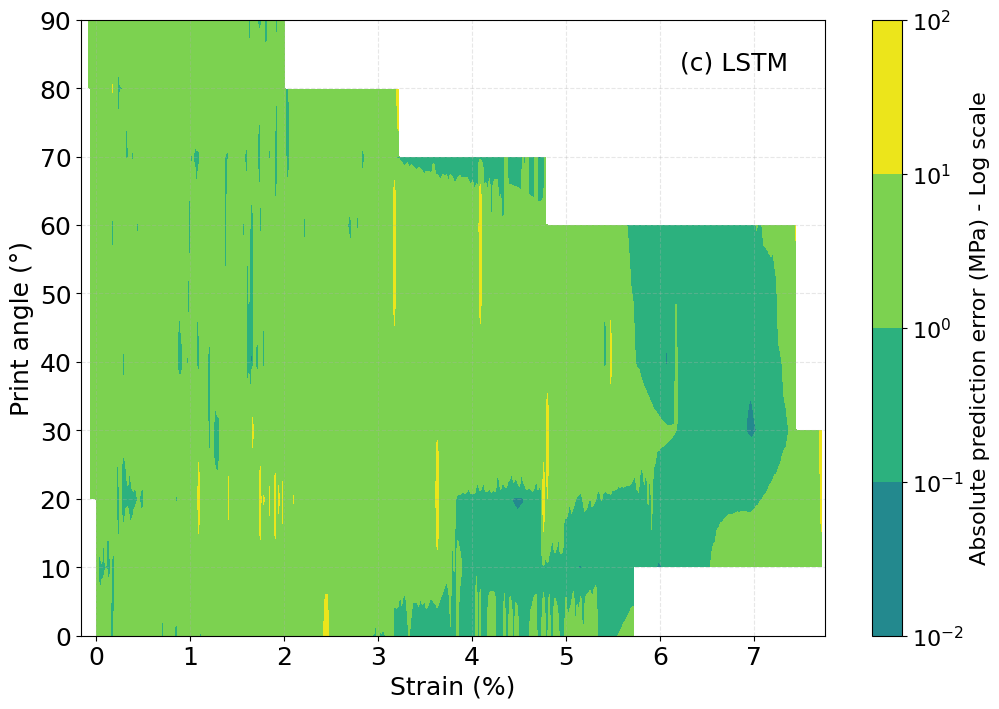


LSTM模型的误差等高线图已保存至: ./lstm_fig/lstm_error_contour_log_scale_formatted.png


In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import joblib

# --- 步骤 1: 加载完整数据集并准备归一化工具 ---
# 确保与您笔记本中的 c6_data 函数逻辑一致
df_full = pd.read_csv('data.csv')
df_full.drop_duplicates(inplace=True)

# 修正列顺序: 第一列是角度, 第二列是应变
x_full = df_full.iloc[:, :2].values
y_full_true_original = df_full.iloc[:, 2].values

# 加载您在训练时保存的scaler
scaler_x = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_x.pkl'))
scaler_y = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_y.pkl'))

# 归一化输入特征
x_full_scaled = scaler_x.transform(x_full)

# --- 步骤 2: 定义并加载您训练好的 Keras LSTM 模型 ---
sequence_length = 10 # 与您训练时使用的序列长度保持一致

# 定义与训练时完全相同的模型结构
model_lstm = Sequential()
model_lstm.add(LSTM(32, input_shape=(sequence_length, x_full_scaled.shape[1]), return_sequences=True))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1))

# 加载模型权重
model_lstm.load_weights('lstmmodel/lstm_weights.h5')
print("LSTM模型权重加载成功。")

# --- 步骤 3: 在完整数据集上进行预测并计算误差 ---
# 为完整数据集创建序列
def create_sequences_full(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

x_full_seq = create_sequences_full(x_full_scaled, sequence_length)

# 进行预测
y_full_pred_scaled = model_lstm.predict(x_full_seq)

# 反归一化预测结果
y_full_pred_original = scaler_y.inverse_transform(y_full_pred_scaled)

# 由于序列预测的原因，我们需要对齐真实值和预测值
# 预测值对应的是从第 (sequence_length - 1) 个点开始的真实值
y_full_true_aligned = y_full_true_original[sequence_length - 1:]
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_aligned.flatten())

# 同样对特征数据进行对齐
strain = x_full[sequence_length - 1:, 1] # 第二列是应变
angle = x_full[sequence_length - 1:, 0]  # 第一列是角度

# 创建用于绘图的DataFrame
df_plot = pd.DataFrame({
    'Strain': strain,
    'Angle': angle,
    'Error': absolute_error
})
print("LSTM模型在完整数据集上的误差计算完成。")


# --- 步骤 4: 使用分步式插值和对数色阶绘图 ---
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())

grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        interp_func = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = interp_func(strain_common)

final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i, s in enumerate(strain_common):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    valid_indices = ~np.isnan(current_errors)
    if np.sum(valid_indices) > 1:
        interp_func_angle = interp1d(
            np.array(valid_angles)[valid_indices],
            np.array(current_errors)[valid_indices],
            bounds_error=False,
            fill_value=np.nan
        )
        final_grid_error[:, i] = interp_func_angle(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

# 绘制最终图表
target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))
final_grid_error_masked = np.ma.masked_invalid(final_grid_error)

# 使用对数归一化 (LogNorm)
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
norm = mcolors.LogNorm(vmin=min_error_for_log, vmax=df_plot['Error'].max())

contour = ax.contourf(target_strain, target_angle, final_grid_error_masked, levels=100, cmap='viridis', norm=norm)

# 格式化图表
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16)
cbar.ax.tick_params(labelsize=16)
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print angle (°)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18)

# 添加子图标签
ax.text(0.95, 0.95, '(c) LSTM', 
        transform=ax.transAxes, 
        fontsize=18,
        ha='right', 
        va='top')

# 保存图像
final_plot_path = './lstm_fig/lstm_error_contour_log_scale_formatted.png'
# 确保文件夹存在
os.makedirs(os.path.dirname(final_plot_path), exist_ok=True)
plt.savefig(final_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nLSTM模型的误差等高线图已保存至: {final_plot_path}")

In [20]:
# 计算并保存 df_plot 与重采样网格（noTL_docs/lstm）——最小改动，不改绘图
import os
import numpy as np
import pandas as pd
import joblib
from scipy.interpolate import interp1d
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1) 在全数据上生成 df_plot（使用已保存的 scaler 与权重）
df_full = pd.read_csv('data.csv')
df_full.drop_duplicates(inplace=True)

# 列顺序：Angle, Strain, Stress
x_full = df_full.iloc[:, :2].values
y_full_true_original = df_full.iloc[:, 2].values

# 加载训练时保存的 scaler
scaler_x = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_x.pkl'))
scaler_y = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_y.pkl'))

x_full_scaled = scaler_x.transform(x_full)

# 加载与训练时一致的 LSTM 结构与权重
sequence_length = 10
model_lstm = Sequential()
model_lstm.add(LSTM(32, input_shape=(sequence_length, x_full_scaled.shape[1]), return_sequences=True))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1))
model_lstm.load_weights('lstmmodel/lstm_weights.h5')

# 序列化函数（与训练一致）
def create_sequences_full(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

x_full_seq = create_sequences_full(x_full_scaled, sequence_length)

# 预测并反归一化
y_full_pred_scaled = model_lstm.predict(x_full_seq)
y_full_pred_original = scaler_y.inverse_transform(y_full_pred_scaled)

# 对齐真实值与特征（序列预测对齐到第 seq_length-1 个样本）
y_full_true_aligned = y_full_true_original[sequence_length - 1:]
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_aligned.flatten())
strain = x_full[sequence_length - 1:, 1]
angle = x_full[sequence_length - 1:, 0]

# 保存 df_plot
df_plot = pd.DataFrame({'Strain': strain, 'Angle': angle, 'Error': absolute_error})
out_dir = './noTL_docs/lstm'
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'df_plot.csv'), index=False)

# 2) 生成重采样网格并保存
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())

grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f(strain_common)

final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i in range(len(strain_common)):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    current_errors = np.array(current_errors)
    valid_angles = np.array(valid_angles)
    valid_mask = ~np.isnan(current_errors)
    if np.sum(valid_mask) > 1:
        g = interp1d(valid_angles[valid_mask], current_errors[valid_mask], bounds_error=False, fill_value=np.nan)
        final_grid_error[:, i] = g(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

np.save(os.path.join(out_dir, 'strain_common.npy'), strain_common)
np.save(os.path.join(out_dir, 'angle_grid_dense.npy'), angle_grid_dense)
np.save(os.path.join(out_dir, 'final_grid_error.npy'), final_grid_error)
np.savez(os.path.join(out_dir, 'lstm_grids.npz'),
         strain_common=strain_common,
         angle_grid_dense=angle_grid_dense,
         final_grid_error=final_grid_error)

print(f"LSTM df_plot 与网格已保存至: {out_dir}")


3236/3236 [==============================] - 5s 1ms/step
LSTM df_plot 与网格已保存至: ./noTL_docs/lstm


In [7]:
# 计算 Angle_group_5.csv 的 MAE / RMSE / R²（全量与 Strain<2.7）并保存
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 确保输出目录
out_dir = os.path.join('lstm_fig', 'prediction')
os.makedirs(out_dir, exist_ok=True)

# 加载 scaler（与训练保持一致）
scaler_x = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_x.pkl'))
scaler_y = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_y.pkl'))

# 读取未见测试集
file_name = 'Angle_group_5.csv'
df_new = pd.read_csv(file_name)

# 特征与真实值（训练时特征顺序为 [Angle, Strain]）
x_new = df_new.iloc[:, :2].values
strain = df_new.iloc[:, 1].values  # 第二列应变
stress_true = df_new.iloc[:, 2].values  # 第三列真实应力

# 归一化 + 构造序列（沿用你已有的函数与序列长度）
x_new_scaled = scaler_x.transform(x_new)
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 准备模型：优先使用当前会话中的 model；若不存在则按训练结构加载权重
try:
    _ = model  # 检查变量是否存在
except NameError:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    model = Sequential()
    model.add(LSTM(32, input_shape=(sequence_length, x_new_scaled.shape[1]), return_sequences=True))
    model.add(LSTM(32))
    model.add(Dense(1))
    model.load_weights('lstmmodel/lstm_weights.h5')

# 预测并反归一化
y_pred_scaled = model.predict(x_new_seq)
stress_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 与绘图一致的对齐方式：用预测长度截断真实量
pred_len = len(stress_pred)
true_all = stress_true[:pred_len].flatten()
strain_all = strain[:pred_len]

# 全量指标
mse_all = mean_squared_error(true_all, stress_pred)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(true_all, stress_pred)
r2_all = r2_score(true_all, stress_pred)

# 阈值内（与绘图一致）：Strain < 2.7
mask = strain_all < 2.7
true_thr = true_all[mask]
pred_thr = stress_pred[mask]

mse_thr = mean_squared_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
rmse_thr = np.sqrt(mse_thr) if np.isfinite(mse_thr) else np.nan
mae_thr = mean_absolute_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
r2_thr = r2_score(true_thr, pred_thr) if len(true_thr) > 1 else np.nan

# 打印结果
print('=== Angle_group_5.csv metrics (LSTM) ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
if np.isfinite(mae_thr):
    print(f'Strain<2.7   -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')
else:
    print('Strain<2.7   -> 无有效样本')

# 保存 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<2.7', 'MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join(out_dir, 'Angle_group_5_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')


78/78 [==============================] - 1s 2ms/step
=== Angle_group_5.csv metrics (LSTM) ===
All samples   -> MAE=0.7983, RMSE=1.1049, R²=0.9936
Strain<2.7   -> MAE=0.7648, RMSE=1.0666, R²=0.9944
Metrics saved to: lstm_fig/prediction/Angle_group_5_metrics.csv


In [7]:
import os, numpy as np, pandas as pd, joblib, tensorflow as tf

STRAIN_MAX = 2.5   # 设为 None 则导出全量
SEQLEN = 10        # 与笔记本一致

# 读取测试集
df = pd.read_csv('Angle_group_5.csv')
x_new = df.iloc[:, :2].values
strain = df.iloc[:, 1].values
stress_true = df.iloc[:, 2].values

# scaler（优先复用内存，否则从磁盘加载）
try:
    _ = scaler_x.mean_; _ = scaler_y.mean_
except Exception:
    scaler_x = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_x.pkl'))
    scaler_y = joblib.load(os.path.join('lstmmodel', 'scalers', 'scaler_y.pkl'))

# 模型（优先复用内存，否则加载）
try:
    model
except NameError:
    try:
        model = tf.keras.models.load_model('./lstmmodel/model_lstm_weight')
    except Exception:
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense
        model = Sequential([
            LSTM(32, input_shape=(SEQLEN, x_new.shape[1]), return_sequences=True),
            LSTM(32),
            Dense(1)
        ])
        model.load_weights('lstmmodel/lstm_weights.h5')

# 构造序列并预测
def make_seq(a, L):
    return np.array([a[i:i+L] for i in range(len(a)-L+1)])
x_scaled = scaler_x.transform(x_new)
x_seq = make_seq(x_scaled, SEQLEN)
y_pred_scaled = model.predict(x_seq, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 对齐（序列预测对应从第 SEQLEN-1 个样本）
strain_aln = strain[SEQLEN-1:SEQLEN-1+len(y_pred)]
true_aln   = stress_true[SEQLEN-1:SEQLEN-1+len(y_pred)]
residual   = y_pred - true_aln

# 筛选
if STRAIN_MAX is not None:
    mask = strain_aln <= STRAIN_MAX
    strain_aln, residual = strain_aln[mask], residual[mask]

# 保存
out_dir = 'lstm_fig/prediction'; os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'residuals_LSTM.csv')
pd.DataFrame({'strain': strain_aln, 'residual': residual}).to_csv(out_path, index=False)
print('saved:', out_path)

saved: lstm_fig/prediction/residuals_LSTM.csv
